In [4]:
# For using EigenMaps' SHAPIQ decompositon method. 

In [5]:
## Load cell 
import os, sys, pickle, importlib, numpy as np, pandas as pd

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
importlib.reload(eigen_steering)
eigen_steering.WEIGHTS_PATH = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/pytorch_base_model/model_fold_0.safetensors'
eigen_steering.RESULTS_DIR = os.path.join(REPO, 'models')
from eigen_steering import EigenMap

lib_path = os.path.join(REPO, 'virtual_perturbations', 'libraries', 'hippo_target_library.pkl')
with open(lib_path, 'rb') as f:
    lib = pickle.load(f)

df = lib['df']
focus_tfs = lib['focus_tfs']

# Build EigenMap — HepG2 first so it plots on top
CT = {'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
em = EigenMap(model_names=CT, device='cuda')

em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

# Build seq_idx -> raw npz index mapping (npz has all seq_valid rows,
# df used the additional keep filter dropping 3 rows)
raw = np.load(lib['attr_npz_path'])
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna()
n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
raw_indices = np.arange(n)[keep]  # filtered_idx -> raw npz idx
del df_full

ohe = em.X.numpy()
idxs = df.seq_idx.values
npz_idxs = raw_indices[idxs]  # correct mapping
for ct in CT:
    hyp = raw[f'attr_{ct}'][npz_idxs]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][npz_idxs]

em.motif_hits = lib['motif_hits']
em.eigen_results = lib['eigen_results']

print(f'Loaded {len(df)} sequences')
print(f'  Conditions: {df["condition"].value_counts().to_dict()}')
print(f'  Focus TFs: {len(focus_tfs)}')
print(f'  Cell type order: {em.cell_types} (top row first)')

EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
Loaded 1059 sequences, X shape: torch.Size([1059, 4, 281])
Loaded 1059 sequences
  Conditions: {'same-diff': 353, 'diff-diff': 353, 'same-same': 353}
  Focus TFs: 151
  Cell type order: ['HepG2', 'K562'] (top row first)


## Context-aware SHAPIQ: background as context player

Players are TF motif hits + one "background" player (enhancer positions not covered by any motif). Promoter and barcode are excluded from interactions (`construct_players=False`).

**Motif order**: the number of motifs in an interaction, ignoring background. E.g. `TEAD1+bg` is motif order 1, `TEAD1+STAT3+bg` is motif order 2. The `-bg` suffix indicates the background player is involved.

**tfmodisco_false_neg**: sequences whose strongest interaction (max |SII|) is pure background — no motif was the top driver. These are flagged and the second-strongest (motif-containing) interaction is used instead. These likely reflect TFMoDISco false negatives where a real motif was missed during annotation.

In [6]:
# Run context-aware SHAPIQ: motifs + background as players
importlib.reload(eigen_steering)
eigen_steering.WEIGHTS_PATH = os.path.join(REPO, 'pytorch_base_model', 'model_fold_0.safetensors')
eigen_steering.RESULTS_DIR = os.path.join(REPO, 'models')
from eigen_steering import EigenMap

# rebuild em with reloaded module
em = EigenMap(model_names=CT, device='cuda')
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})
ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][npz_idxs]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][npz_idxs]
em.motif_hits = lib['motif_hits']
em.eigen_results = lib['eigen_results']

n_rep = 30
seed = 42
max_order = 4
cache_dir = os.path.join(REPO, 'syntax_SHAPIQ', 'cache')

ctx_results = em.shapley_interaction_index_context(
    seq_idx=None, max_order=max_order,
    n_rep=n_rep, batch_size=516, random_state=seed,
    cache_dir=cache_dir,
)

EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
Loaded 1059 sequences, X shape: torch.Size([1059, 4, 281])
  Loading HepG2: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/checkpoints/best_stage2.pt
  Loading K562: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/checkpoints/best_stage2.pt
  shapley context (necessity): 1059/1059 sequences
  Saved shapley_interaction_index_context cache: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/syntax_SHAPIQ/cache/shapley_interaction_index_context_e902179538d018e2293e0fe703f96d50.pkl


In [7]:
# Collect into flat dataframe
ctx_rows = []
for si, res in enumerate(ctx_results):
    if res is None:
        continue
    for act, act_res in res.items():
        if act_res['n_players'] == 0:
            continue
        player_names = act_res['motifs']
        player_types = act_res['player_types']
        for interaction_key, ct_scores in act_res['interactions'].items():
            order = len(interaction_key)
            tf_names = '+'.join(player_names[i] for i in interaction_key) if order > 0 else 'null'
            types_in = [player_types[i] for i in interaction_key] if order > 0 else ['null']
            types_set = set(types_in)
            if order == 0:
                itype = 'null'
            elif order == 1:
                t = types_in[0]
                itype = tf_names if t == 'motif' else 'background'
            else:
                has_bg = 'background' in types_set
                motif_names = [player_names[i] for i, t in zip(interaction_key, types_in) if t == 'motif']
                if len(motif_names) == 0:
                    itype = 'background'
                else:
                    itype = '+'.join(motif_names)
                    if has_bg:
                        itype += '+bg'
            for ct, score in ct_scores.items():
                ctx_rows.append({
                    'seq_idx': si,
                    'annotation_ct': act,
                    'scoring_ct': ct,
                    'interaction': interaction_key,
                    'tf_names': tf_names,
                    'order': order,
                    'itype': itype,
                    'sii_score': score,
                    'EI_1_vxr': df.iloc[si]['EI_1 var x r'],
                    'condition': df.iloc[si]['condition'],
                })

ctx_df = pd.DataFrame(ctx_rows)

# Normalize: sii_frac = |sii_score| / total |sii_score| per (seq, annotation_ct, scoring_ct)
ctx_df['abs_sii'] = ctx_df['sii_score'].abs()
total_pool = ctx_df[ctx_df.order >= 1].groupby(['seq_idx', 'annotation_ct', 'scoring_ct'])['abs_sii'].transform('sum')
ctx_df['sii_frac'] = 0.0
mask = ctx_df.order >= 1
ctx_df.loc[mask, 'sii_frac'] = ctx_df.loc[mask, 'abs_sii'] / total_pool

print(f'{len(ctx_df)} rows, {ctx_df.seq_idx.nunique()} sequences, max order {ctx_df.order.max()}')

# Per-sequence max sii_frac (diagonal only) — matches the plot below
diag_summary = ctx_df[(ctx_df.annotation_ct == ctx_df.scoring_ct) & (ctx_df.order >= 1)]
per_seq_max = diag_summary.loc[diag_summary.groupby('seq_idx')['sii_frac'].idxmax()]
print(f'\nPer-seq max sii_frac — top 15 itypes:')
print(per_seq_max['itype'].value_counts().head(15).to_string())
print(f'\nPer-seq max sii_frac — by order:')
print(per_seq_max['order'].value_counts().sort_index().to_string())

22844 rows, 1059 sequences, max order 4

Per-seq max sii_frac — top 15 itypes:
itype
background    560
HNF1A          69
REST           50
ZNF841         37
NFYC           20
XBP1           17
ZBTB11         14
TGIF1          11
MAZ            11
Banp           10
SP1            10
ATF4            9
POU6F1          8
ZNF131          8
NFYB            8

Per-seq max sii_frac — by order:
order
1    1019
2      35
3       5


tfmodisco_false_neg: 714 / 1596 rows


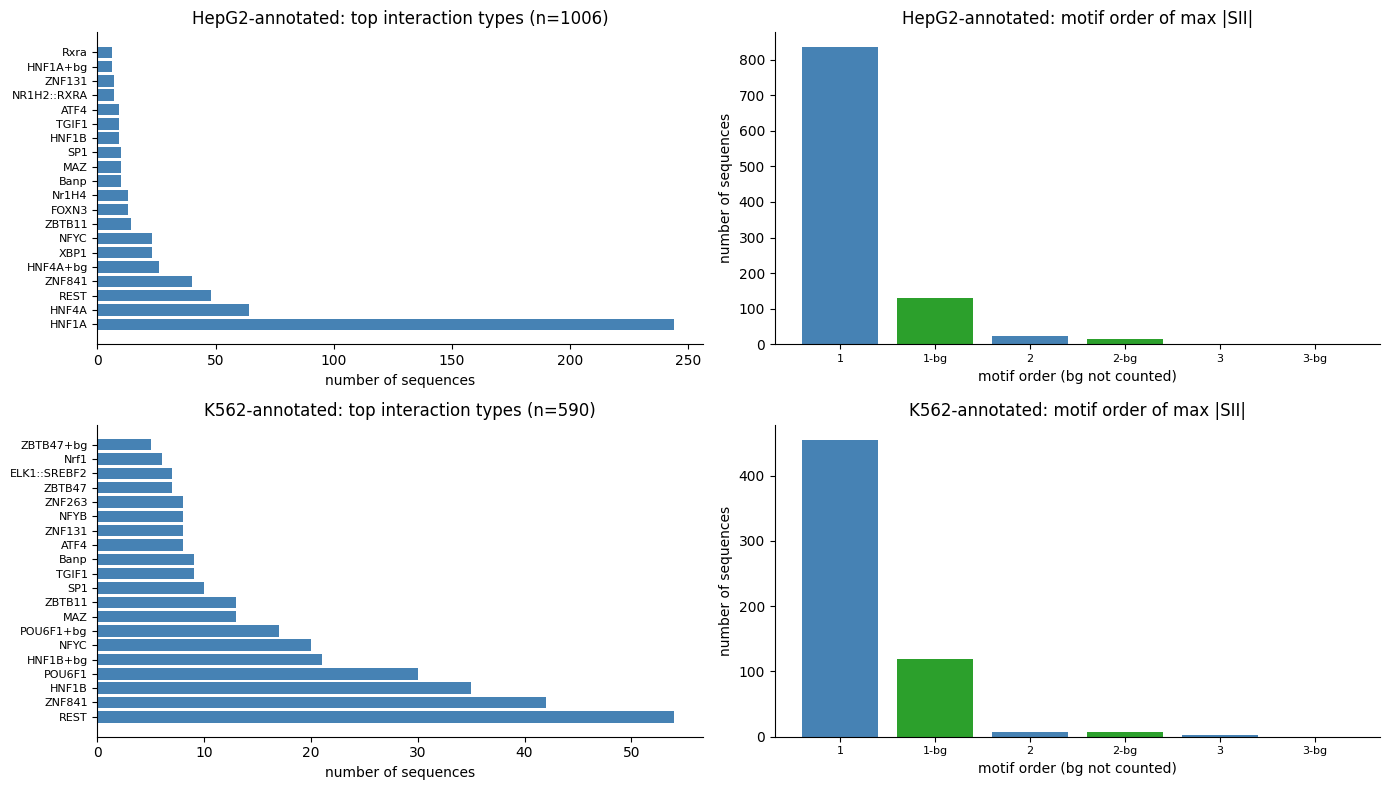

In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def itype_color(itype, all_itypes):
    """Color by TF identity. Background = green, TF combos = tab20 palette."""
    if itype in ('null', 'background'):
        return '#2ca02c'
    if '+bg' in itype:
        base = itype.replace('+bg', '')
        tf_only = [t for t in all_itypes if t not in ('null', 'background') and '+bg' not in t]
        idx = tf_only.index(base) if base in tf_only else 0
        return cm.Greens(0.4 + (idx % 8) * 0.07)
    tf_only = [t for t in all_itypes if t not in ('null', 'background') and '+bg' not in t]
    idx = tf_only.index(itype) if itype in tf_only else 0
    return cm.tab20(idx / max(len(tf_only), 1))

# Per-sequence max |SII| interaction (diagonal only, order >= 1)
diag = ctx_df[(ctx_df.annotation_ct == ctx_df.scoring_ct) & (ctx_df.order >= 1)].copy()

def motif_order(row):
    if row['itype'] == 'background':
        return 0
    parts = row['itype'].replace('+bg', '').split('+')
    return len(parts)

diag['motif_order'] = diag.apply(motif_order, axis=1)
diag['has_bg'] = diag['itype'].apply(lambda x: x == 'background' or '+bg' in x)

def order_label(row):
    return f"{row['motif_order']}-bg" if row['has_bg'] else str(row['motif_order'])

diag['order_label'] = diag.apply(order_label, axis=1)

# For each (seq, annotation_ct): max abs_sii. If pure bg, take 2nd max and flag
max_idx = diag.groupby(['seq_idx', 'annotation_ct'])['abs_sii'].idxmax()
max_rows = diag.loc[max_idx].copy()

bg_mask = max_rows['itype'] == 'background'
bg_keys = max_rows.loc[bg_mask, ['seq_idx', 'annotation_ct']]
fallback_rows = []
for _, bk in bg_keys.iterrows():
    seq_diag = diag[(diag['seq_idx'] == bk['seq_idx']) &
                    (diag['annotation_ct'] == bk['annotation_ct']) &
                    (diag['itype'] != 'background')]
    if len(seq_diag) > 0:
        fallback_rows.append(seq_diag.loc[seq_diag['abs_sii'].idxmax()])
if fallback_rows:
    fallback_df = pd.DataFrame(fallback_rows)
    max_rows = pd.concat([max_rows[~bg_mask], fallback_df])

bg_seqs_all = bg_keys['seq_idx'].unique()
max_rows['tfmodisco_false_neg'] = max_rows['seq_idx'].isin(bg_seqs_all)
print(f'tfmodisco_false_neg: {max_rows["tfmodisco_false_neg"].sum()} / {len(max_rows)} rows')

# --- Plot: 2x2 grid, rows = HepG2 / K562, cols = top itypes / motif order ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row_i, ct in enumerate(['HepG2', 'K562']):
    sub = max_rows[max_rows.annotation_ct == ct]

    # Left: top 20 interaction types
    ax = axes[row_i, 0]
    itype_counts = sub['itype'].value_counts().head(20)
    ax.barh(range(len(itype_counts)), itype_counts.values, color='steelblue')
    ax.set_yticks(range(len(itype_counts)))
    ax.set_yticklabels(itype_counts.index, fontsize=8)
    ax.set_xlabel('number of sequences')
    ax.set_title(f'{ct}-annotated: top interaction types (n={len(sub)})')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Right: motif order with bg split
    ax = axes[row_i, 1]
    all_orders = sorted(sub['motif_order'].unique())
    tick_labels = []
    for o in all_orders:
        tick_labels.append(str(o))
        tick_labels.append(f'{o}-bg')
    counts = [sub[sub['order_label'] == lbl].shape[0] for lbl in tick_labels]
    colors = ['steelblue' if '-bg' not in lbl else '#2ca02c' for lbl in tick_labels]
    ax.bar(range(len(tick_labels)), counts, color=colors)
    ax.set_xticks(range(len(tick_labels)))
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_xlabel('motif order (bg not counted)')
    ax.set_ylabel('number of sequences')
    ax.set_title(f'{ct}-annotated: motif order of max |SII|')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/n-SHAPIQ_overview.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Compare 1-SII (Shapley values) to necessity scores from KO experiments
import os, pickle
from scipy.stats import pearsonr

CONTEXT_PLAYERS = ('background',)
TOP_N = 10
LEGEND_COLORS = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
                 '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990']

# Exclude tfmodisco false negatives
false_neg_seqs = set(max_rows[max_rows['tfmodisco_false_neg']]['seq_idx'].values)
ctx_filtered = ctx_df[~ctx_df['seq_idx'].isin(false_neg_seqs)]
print(f'Excluding {len(false_neg_seqs)} tfmodisco_false_neg sequences, {ctx_filtered.seq_idx.nunique()} remain')

# 1. Load necessity results
nec_path = os.path.join(REPO, 'virtual_perturbations', 'results',
                        'virtual_perturbation_results_60_seed42.pkl')
with open(nec_path, 'rb') as f:
    nec_data = pickle.load(f)

nec_rows = []
for si, tests in enumerate(nec_data['necessity']):
    if tests is None or si in false_neg_seqs:
        continue
    for t in tests:
        if t['order'] != 1:
            continue
        tf = t['motifs'][0]['tf']
        act = t['annotation_ct']
        nec_scores = {ct: -t['scores'][ct] for ct in t['scores']}
        nec_rows.append({
            'seq_idx': si,
            'annotation_ct': act,
            'tf': tf,
            'player_type': tf if tf in CONTEXT_PLAYERS else 'motif',
            'nec_HepG2': nec_scores.get('HepG2', np.nan),
            'nec_K562': nec_scores.get('K562', np.nan),
        })
nec_df = pd.DataFrame(nec_rows)
print(f'Necessity df: {len(nec_df)} rows ({(nec_df.player_type=="motif").sum()} motif, '
      f'{(nec_df.player_type!="motif").sum()} context)')

# 2. Extract order-1 rows (diagonal)
sii1 = ctx_filtered[(ctx_filtered.order == 1) &
                     (ctx_filtered.annotation_ct == ctx_filtered.scoring_ct)].copy()
sii1 = sii1[sii1['itype'] != 'background']
sii1['tf'] = sii1['tf_names']
print(f'1-SII rows: {len(sii1)}')

# 3. Merge on seq_idx + annotation_ct + tf
merged = sii1.merge(nec_df, on=['seq_idx', 'annotation_ct', 'tf'], how='inner')
merged['nec_matched'] = np.where(
    merged.annotation_ct == 'HepG2', merged.nec_HepG2, merged.nec_K562
)
print(f'Merged: {len(merged)} rows')

# 4. Plot: scatter (raw sii_score vs necessity) + histogram (sii_frac)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for col, act in enumerate(['HepG2', 'K562']):
    # Per-cell-type top itypes
    act_sii = sii1[sii1.annotation_ct == act]
    top_act = act_sii.groupby('itype')['sii_frac'].mean().sort_values(ascending=False).head(TOP_N)
    top_names = top_act.index.tolist()
    top_color = {name: LEGEND_COLORS[i % len(LEGEND_COLORS)] for i, name in enumerate(top_names)}

    # Scatter: raw sii_score vs necessity
    ax = axes[0, col]
    sub = merged[merged.annotation_ct == act]
    other = sub[~sub.itype.isin(top_names)]
    ax.scatter(other.sii_score, other.nec_matched, color='#cccccc', s=8, alpha=0.3, edgecolors='none')
    for name in top_names:
        s = sub[sub.itype == name]
        if len(s) > 0:
            ax.scatter(s.sii_score, s.nec_matched,
                       color=top_color[name], label=name, s=12, alpha=0.6, edgecolors='none')
    r, p = pearsonr(sub.sii_score, sub.nec_matched)
    ax.axhline(0, c='k', lw=0.3); ax.axvline(0, c='k', lw=0.3)

    # Label most redundant (low nec, high |SII|) and most synergistic (high nec, low |SII|)
    sub = sub.copy()
    sub['residual'] = sub.sii_score.abs() - sub.nec_matched.abs()
    top_redundant = sub.nlargest(5, 'residual')
    top_synergistic = sub.nsmallest(5, 'residual')
    for _, row in top_redundant.iterrows():
        ax.annotate(row.tf, (row.sii_score, row.nec_matched),
                     fontsize=5, color='red', alpha=0.8)
    for _, row in top_synergistic.iterrows():
        ax.annotate(row.tf, (row.sii_score, row.nec_matched),
                     fontsize=5, color='blue', alpha=0.8)

    ax.set_xlabel('1-SII score'); ax.set_ylabel('Necessity')
    ax.set_title(f'{act} (r={r:.3f}, p={p:.1e})')
    ax.legend(fontsize=6)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Distribution of sii_frac with mean markers
    ax = axes[1, col]
    sub_hist = act_sii
    other_vals = sub_hist[~sub_hist.itype.isin(top_names)]['sii_frac'].dropna()
    ax.hist(other_vals, bins=40, alpha=0.3, color='#cccccc')
    for name in top_names:
        vals = sub_hist[sub_hist.itype == name]['sii_frac'].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=40, alpha=0.5, color=top_color[name])
            ax.axvline(vals.mean(), color=top_color[name], lw=1.5, ls='--', label=f'{name} (\u03bc={vals.mean():.3f})')
    ax.set_xlabel('1-SII frac'); ax.set_ylabel('Count')
    ax.set_title(f'{act} 1-SII frac distribution')
    ax.legend(fontsize=6)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('1-SII: score vs Necessity + frac distribution', fontsize=12)
plt.tight_layout()
plt.show()

Excluding 618 tfmodisco_false_neg sequences, 441 remain


FileNotFoundError: [Errno 2] No such file or directory: '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/virtual_perturbations/results/virtual_perturbation_results_60_seed42.pkl'

2-SII rows: 3154
806 unique itypes


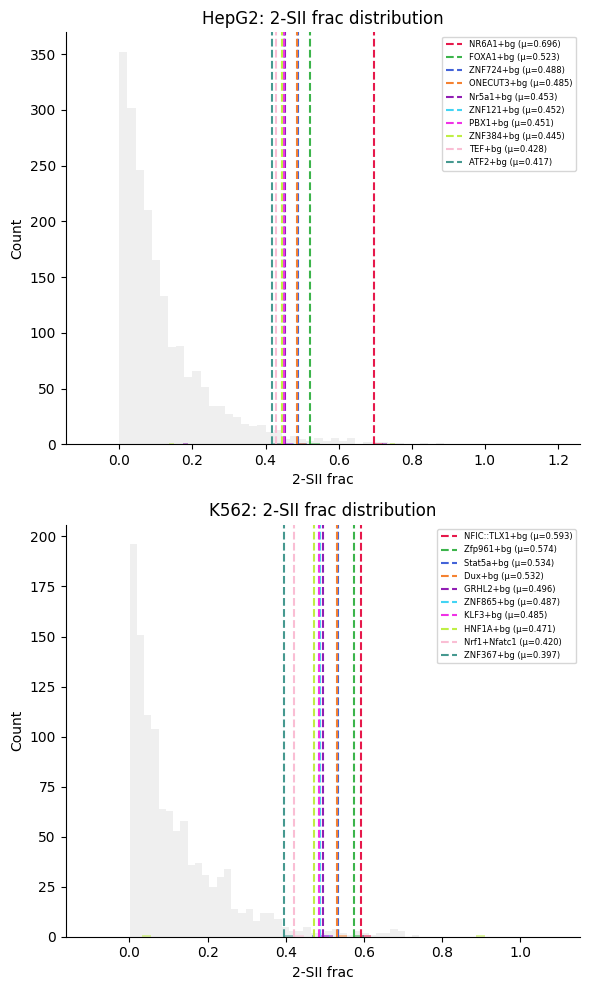

In [ ]:
# 2-SII focused: scatter (raw score) vs necessity + histogram (sii_frac)
from scipy.stats import pearsonr

sii2 = ctx_filtered[(ctx_filtered.order == 2) &
                     (ctx_filtered.annotation_ct == ctx_filtered.scoring_ct)].copy()
sii2['tf_pair'] = sii2['tf_names'].apply(lambda x: '+'.join(sorted(x.split('+'))))
print(f'2-SII rows: {len(sii2)}')

print(f'{sii2.itype.nunique()} unique itypes')

merged2 = None
if 'nec_data' in dir():
    nec2_rows = []
    for si, tests in enumerate(nec_data['necessity']):
        if tests is None or si in false_neg_seqs:
            continue
        for t in tests:
            if t['order'] != 2:
                continue
            tfs = '+'.join(sorted(m['tf'] for m in t['motifs']))
            act = t['annotation_ct']
            nec_scores = {ct: -t['scores'][ct] for ct in t['scores']}
            nec2_rows.append({
                'seq_idx': si, 'annotation_ct': act, 'tf_pair': tfs,
                'nec_HepG2': nec_scores.get('HepG2', np.nan),
                'nec_K562': nec_scores.get('K562', np.nan),
            })
    if nec2_rows:
        nec2_df = pd.DataFrame(nec2_rows)
        merged2 = sii2.merge(nec2_df, on=['seq_idx', 'annotation_ct', 'tf_pair'], how='inner')
        merged2['nec_score_matched'] = np.where(
            merged2.annotation_ct == 'HepG2', merged2.nec_HepG2, merged2.nec_K562)
        print(f'Merged with necessity: {len(merged2)} rows')

ncols = 2 if merged2 is not None and len(merged2) > 0 else 1
fig, axes = plt.subplots(2, ncols, figsize=(6 * ncols, 10))
if ncols == 1:
    axes = axes.reshape(2, 1)

for row_i, act in enumerate(['HepG2', 'K562']):
    act_sii = sii2[sii2.annotation_ct == act]
    top_act = act_sii.groupby('itype')['sii_frac'].mean().sort_values(ascending=False).head(TOP_N)
    top_names_2 = top_act.index.tolist()
    top_color_2 = {name: LEGEND_COLORS[i % len(LEGEND_COLORS)] for i, name in enumerate(top_names_2)}
    col = 0
    if ncols == 2:
        ax = axes[row_i, 0]
        sub = merged2[merged2.annotation_ct == act]
        other = sub[~sub.itype.isin(top_names_2)]
        ax.scatter(other.sii_score, other.nec_score_matched, color='#cccccc', s=8, alpha=0.3, edgecolors='none')
        for name in top_names_2:
            s = sub[sub.itype == name]
            if len(s) > 0:
                ax.scatter(s.sii_score, s.nec_score_matched,
                           color=top_color_2[name], label=name, s=12, alpha=0.6, edgecolors='none')
        ax.axhline(0, c='k', lw=0.3); ax.axvline(0, c='k', lw=0.3)
        ax.set_xlabel('2-SII score'); ax.set_ylabel('Necessity (order-2 KO)')
        if len(sub) > 2:
            r, _ = pearsonr(sub.sii_score, sub.nec_score_matched)
            ax.set_title(f'{act}-annotated (r={r:.2f}, n={len(sub)})')
        else:
            ax.set_title(f'{act}-annotated (n={len(sub)})')
        ax.legend(fontsize=6)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        col = 1

    ax = axes[row_i, col]
    sub_hist = act_sii
    other_vals = sub_hist[~sub_hist.itype.isin(top_names_2)]['sii_frac'].dropna()
    ax.hist(other_vals, bins=40, alpha=0.3, color='#cccccc')
    for name in top_names_2:
        vals = sub_hist[sub_hist.itype == name]['sii_frac'].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=40, alpha=0.5, color=top_color_2[name])
            ax.axvline(vals.mean(), color=top_color_2[name], lw=1.5, ls='--', label=f'{name} (\u03bc={vals.mean():.3f})')
    ax.set_xlabel('2-SII frac'); ax.set_ylabel('Count')
    ax.set_title(f'{act}: 2-SII frac distribution')
    ax.legend(fontsize=6)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

3-SII rows: 1174
706 unique itypes


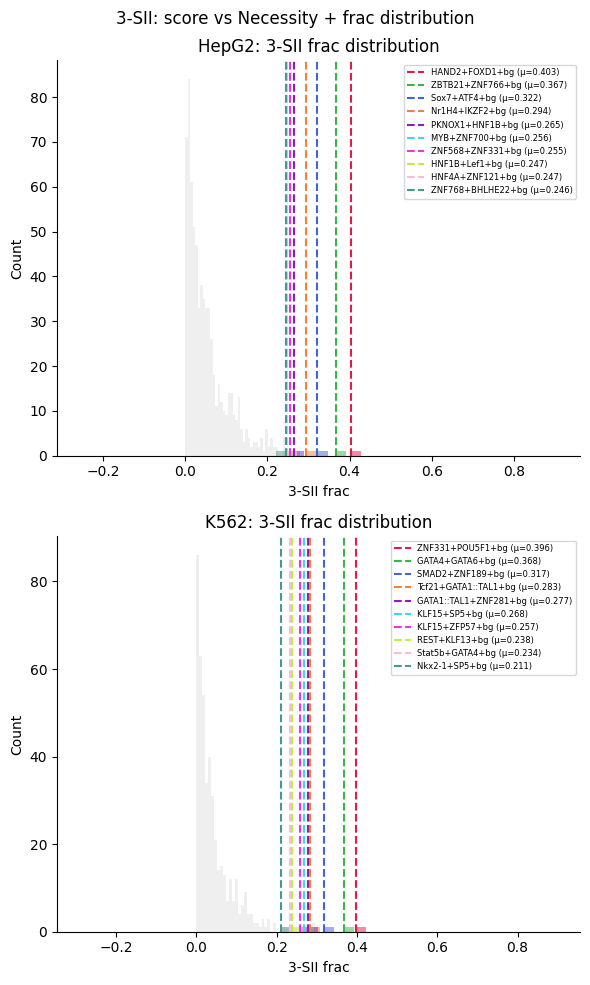

In [ ]:
# 3-SII focused: scatter (raw score) vs necessity + histogram (sii_frac)

sii3 = ctx_filtered[(ctx_filtered.order == 3) &
                     (ctx_filtered.annotation_ct == ctx_filtered.scoring_ct)].copy()
sii3['tf_triple'] = sii3['tf_names'].apply(lambda x: '+'.join(sorted(x.split('+'))))
print(f'3-SII rows: {len(sii3)}')

print(f'{sii3.itype.nunique()} unique itypes')

merged3 = None
if 'nec_data' in dir():
    nec3_rows = []
    for si, tests in enumerate(nec_data['necessity']):
        if tests is None or si in false_neg_seqs:
            continue
        for t in tests:
            if t['order'] != 3:
                continue
            tfs = '+'.join(sorted(m['tf'] for m in t['motifs']))
            act = t['annotation_ct']
            nec_scores = {ct: -t['scores'][ct] for ct in t['scores']}
            nec3_rows.append({
                'seq_idx': si, 'annotation_ct': act, 'tf_triple': tfs,
                'nec_HepG2': nec_scores.get('HepG2', np.nan),
                'nec_K562': nec_scores.get('K562', np.nan),
            })
    if nec3_rows:
        nec3_df = pd.DataFrame(nec3_rows)
        merged3 = sii3.merge(nec3_df, on=['seq_idx', 'annotation_ct', 'tf_triple'], how='inner')
        merged3['nec_score_matched'] = np.where(
            merged3.annotation_ct == 'HepG2', merged3.nec_HepG2, merged3.nec_K562)
        print(f'Merged with necessity: {len(merged3)} rows')

ncols = 2 if merged3 is not None and len(merged3) > 0 else 1
fig, axes = plt.subplots(2, ncols, figsize=(6 * ncols, 10))
if ncols == 1:
    axes = axes.reshape(2, 1)

for row_i, act in enumerate(['HepG2', 'K562']):
    act_sii = sii3[sii3.annotation_ct == act]
    top_act = act_sii.groupby('itype')['sii_frac'].mean().sort_values(ascending=False).head(TOP_N)
    top_names_3 = top_act.index.tolist()
    top_color_3 = {name: LEGEND_COLORS[i % len(LEGEND_COLORS)] for i, name in enumerate(top_names_3)}
    col = 0
    if ncols == 2:
        ax = axes[row_i, 0]
        sub = merged3[merged3.annotation_ct == act]
        other = sub[~sub.itype.isin(top_names_3)]
        ax.scatter(other.sii_score, other.nec_score_matched, color='#cccccc', s=8, alpha=0.3, edgecolors='none')
        for name in top_names_3:
            s = sub[sub.itype == name]
            if len(s) > 0:
                ax.scatter(s.sii_score, s.nec_score_matched,
                           color=top_color_3[name], label=name, s=12, alpha=0.6, edgecolors='none')
        ax.axhline(0, c='k', lw=0.3); ax.axvline(0, c='k', lw=0.3)
        ax.set_xlabel('3-SII score'); ax.set_ylabel('Necessity (order-3 KO)')
        if len(sub) > 2:
            r, _ = pearsonr(sub.sii_score, sub.nec_score_matched)
            ax.set_title(f'{act}-annotated (r={r:.2f}, n={len(sub)})')
        else:
            ax.set_title(f'{act}-annotated (n={len(sub)})')
        ax.legend(fontsize=6)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        col = 1

    ax = axes[row_i, col]
    sub_hist = act_sii
    other_vals = sub_hist[~sub_hist.itype.isin(top_names_3)]['sii_frac'].dropna()
    ax.hist(other_vals, bins=40, alpha=0.3, color='#cccccc')
    for name in top_names_3:
        vals = sub_hist[sub_hist.itype == name]['sii_frac'].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=40, alpha=0.5, color=top_color_3[name])
            ax.axvline(vals.mean(), color=top_color_3[name], lw=1.5, ls='--', label=f'{name} (\u03bc={vals.mean():.3f})')
    ax.set_xlabel('3-SII frac'); ax.set_ylabel('Count')
    ax.set_title(f'{act}: 3-SII frac distribution')
    ax.legend(fontsize=6)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('3-SII: score vs Necessity + frac distribution', fontsize=12)
plt.tight_layout()
plt.show()

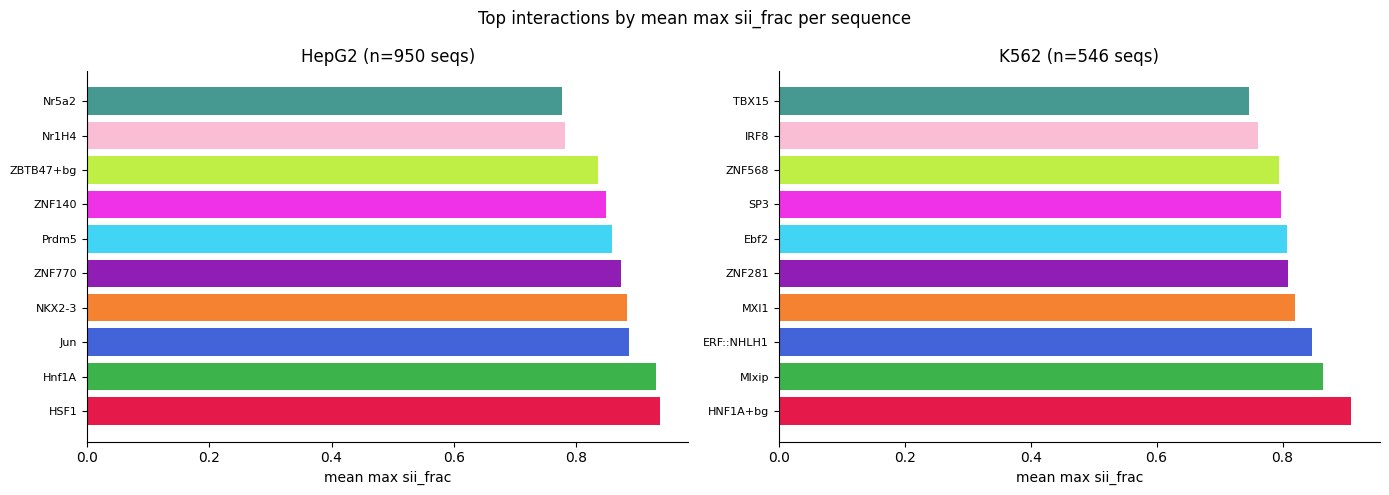

In [ ]:
# Max sii_frac per sequence per cell line — if bg is max, take next best
diag = ctx_filtered[(ctx_filtered.annotation_ct == ctx_filtered.scoring_ct) & (ctx_filtered.order >= 1)]
max_rows_ct = diag.loc[diag.groupby(['seq_idx', 'scoring_ct'])['sii_frac'].idxmax()]

# Fallback for seqs where bg is max
bg_mask = max_rows_ct['itype'] == 'background'
bg_keys = max_rows_ct.loc[bg_mask, ['seq_idx', 'scoring_ct']]
non_bg = diag[diag['itype'] != 'background']
fallback = []
for _, row in bg_keys.iterrows():
    sub = non_bg[(non_bg['seq_idx'] == row['seq_idx']) & (non_bg['scoring_ct'] == row['scoring_ct'])]
    if len(sub) > 0:
        fallback.append(sub.loc[sub['sii_frac'].idxmax()])
if fallback:
    max_rows_ct = pd.concat([max_rows_ct[~bg_mask], pd.DataFrame(fallback)])

# Bar chart: mean of max sii_frac per itype, per cell line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ct in zip(axes, ['HepG2', 'K562']):
    sub = max_rows_ct[max_rows_ct.scoring_ct == ct]
    means = sub.groupby('itype')['sii_frac'].mean().sort_values(ascending=False).head(TOP_N)
    colors = [LEGEND_COLORS[i % len(LEGEND_COLORS)] for i in range(len(means))]
    ax.barh(range(len(means)), means.values, color=colors)
    ax.set_yticks(range(len(means)))
    ax.set_yticklabels(means.index, fontsize=8)
    ax.set_xlabel('mean max sii_frac')
    ax.set_title(f'{ct} (n={len(sub)} seqs)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Top interactions by mean max sii_frac per sequence', fontsize=12)
plt.tight_layout()
plt.savefig('../results/n-SHAPIQ_results.png', dpi=300, bbox_inches='tight')
plt.show()